# Mental Health Twitter - Sentiment Analysis
This notebook performs sentiment analysis on mental health tweets using TextBlob, then classifies them using a KNN model.

## 1. Setup & Imports

In [1]:
!pip install -q textblob nltk spacy
!python -m spacy download en_core_web_sm -q

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob, Word

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## 2. Load Data

In [3]:
df = pd.read_csv("Mental-Health-Twitter.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (20000, 11)


,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


In [4]:
# Check for missing values
df.isnull().sum()

Unnamed: 0      0
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64

## 3. Preprocessing
We keep only the `post_text` column, then clean the text by lowercasing, removing numbers, punctuation, and stopwords, and finally lemmatize the words.

In [5]:
df = df[['post_text']].copy()

# Lowercase
df["post_text"] = df["post_text"].str.lower()

# Remove numbers and punctuation
df["post_text"] = df["post_text"].str.replace(r"\d", "", regex=True)
df["post_text"] = df["post_text"].str.replace(r"[^\w\s]", "", regex=True)

# Remove stopwords
sw = set(stopwords.words("english"))
df["post_text"] = df["post_text"].apply(lambda x: " ".join(w for w in x.split() if w not in sw))

# Lemmatization
df["post_text"] = df["post_text"].apply(lambda x: " ".join([Word(w).lemmatize() for w in x.split()]))

df.head()

,post_text
0,year since diagnosed anxiety depression today ...
1,sunday need break im planning spend little tim...
2,awake tired need sleep brain idea
3,rt sewhq retro bear make perfect gift great be...
4,hard say whether packing list making life easi...


In [6]:
# Tokenize
df["tokens"] = df["post_text"].apply(lambda x: TextBlob(x).words)
df.head()

,post_text,tokens
0,year since diagnosed anxiety depression today ...,"[year, since, diagnosed, anxiety, depression, ..."
1,sunday need break im planning spend little tim...,"[sunday, need, break, im, planning, spend, lit..."
2,awake tired need sleep brain idea,"[awake, tired, need, sleep, brain, idea]"
3,rt sewhq retro bear make perfect gift great be...,"[rt, sewhq, retro, bear, make, perfect, gift, ..."
4,hard say whether packing list making life easi...,"[hard, say, whether, packing, list, making, li..."


## 4. Sentiment Analysis

We use **TextBlob** to get a polarity score for each tweet, ranging from -1 (very negative) to +1 (very positive). Tweets with polarity >= 0 are labeled **Positive**, and the rest **Negative**.

In [7]:
# Get polarity and subjectivity scores
sentiments = df["post_text"].apply(lambda x: TextBlob(x).sentiment)
df["polarity"] = sentiments.apply(lambda s: s.polarity)

# Label sentiment
df["Sentiment"] = np.where(df["polarity"] >= 0, "Positive", "Negative")

df[['post_text', 'tokens', 'polarity', 'Sentiment']].head(6)

,post_text,tokens,polarity,Sentiment
0,year since diagnosed anxiety depression today ...,"[year, since, diagnosed, anxiety, depression, ...",0.100000,Positive
1,sunday need break im planning spend little tim...,"[sunday, need, break, im, planning, spend, lit...",-0.093750,Negative
2,awake tired need sleep brain idea,"[awake, tired, need, sleep, brain, idea]",-0.400000,Negative
3,rt sewhq retro bear make perfect gift great be...,"[rt, sewhq, retro, bear, make, perfect, gift, ...",0.900000,Positive
4,hard say whether packing list making life easi...,"[hard, say, whether, packing, list, making, li...",-0.045833,Negative
5,making packing list new hobby movinghouse,"[making, packing, list, new, hobby, movinghouse]",0.136364,Positive


## 5. Exploratory Analysis

Sentiment
Negative     3563
Positive    16437
Name: post_text, dtype: int64


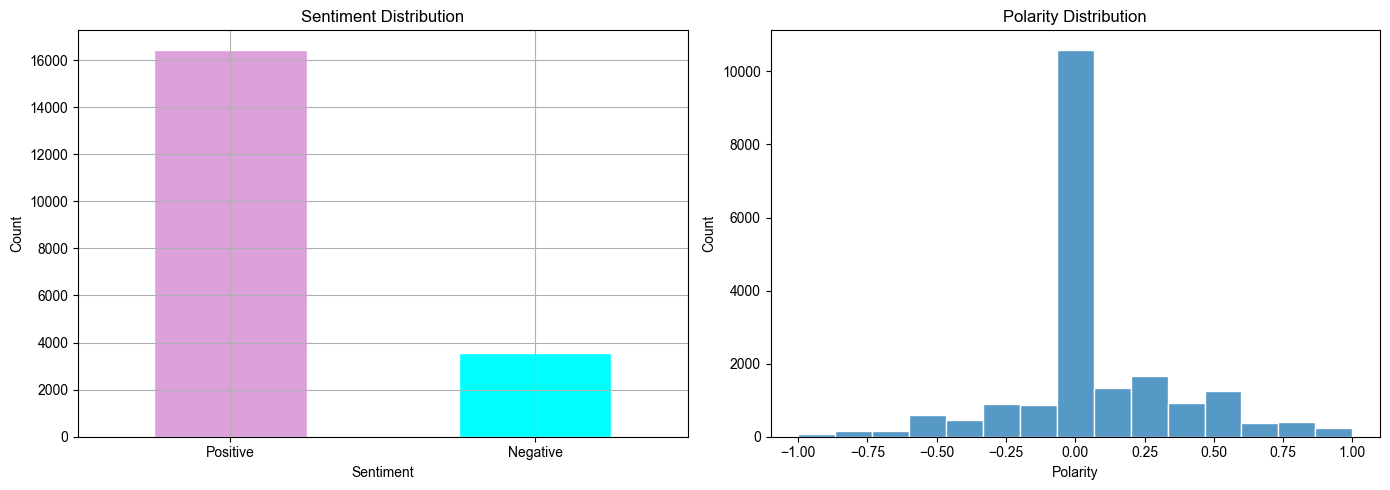

In [8]:
# Sentiment counts
print(df.groupby("Sentiment")["post_text"].count())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of sentiment counts
sns.set_style("whitegrid")
df["Sentiment"].value_counts().plot(kind="bar", ax=axes[0], rot=0, color=["plum", "cyan"])
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

# Polarity distribution
sns.histplot(df['polarity'], bins=15, kde=False, ax=axes[1])
axes[1].set_title("Polarity Distribution")
axes[1].set_xlabel("Polarity")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [9]:
# Most negative tweets (lowest polarity)
df[['post_text', 'polarity']].sort_values('polarity').head(5)

,post_text,polarity
61,sarah_booker yorkshireguy urgh awful,-1.0
63,sarah_booker dear god horrific image awful awf...,-1.0
3587,rt brisonaintshiit anxiety worst thing someone...,-1.0
49,offensivebanter awful,-1.0
5012,health boring,-1.0


## 6. KNN Classifier

We convert tweet text into numerical features using **CountVectorizer**, then train a **K-Nearest Neighbors** classifier to predict sentiment.

In [10]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df['post_text'], df['Sentiment'], test_size=0.2, random_state=42
)

# Vectorize text
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train KNN
knn = KNeighborsClassifier()
knn.fit(X_train_vec, y_train)

# Evaluate
y_pred = knn.predict(X_test_vec)
print(f"Accuracy: {round(accuracy_score(y_test, y_pred) * 100, 2)}%")

Accuracy: 84.15%


In [11]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.79      0.17      0.28       727
    Positive       0.84      0.99      0.91      3273

    accuracy                           0.84      4000
   macro avg       0.82      0.58      0.60      4000
weighted avg       0.83      0.84      0.80      4000



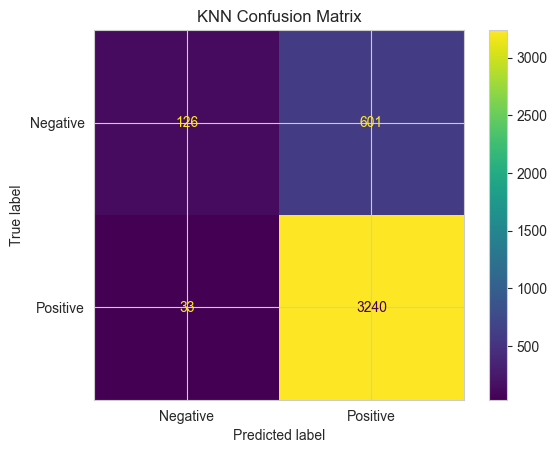

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_).plot()
plt.title("KNN Confusion Matrix")
plt.show()

## 7. Test with Your Own Input

Type any tweet-like text below and the classifier will predict whether it's **Positive** or **Negative**, along with the TextBlob polarity score.

In [13]:
def preprocess_input(text):
    """Apply the same cleaning steps used during training."""
    text = text.lower()
    text = ''.join(c for c in text if not c.isdigit())
    text = ''.join(c for c in text if c.isalnum() or c.isspace())
    text = ' '.join(w for w in text.split() if w not in sw)
    text = ' '.join(Word(w).lemmatize() for w in text.split())
    return text

def predict_sentiment(text):
    cleaned = preprocess_input(text)
    polarity = TextBlob(cleaned).sentiment.polarity
    vec = vectorizer.transform([cleaned])
    prediction = knn.predict(vec)[0]
    print(f"Input     : {text}")
    print(f"Cleaned   : {cleaned}")
    print(f"Polarity  : {round(polarity, 4)}")
    print(f"Prediction: {prediction}")

In [14]:
# --- Change this to whatever you want to test ---
user_input = ""

predict_sentiment(user_input)

Input     : anxiety
Cleaned   : anxiety
Polarity  : 0.0
Prediction: Positive
